In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
import seaborn as sns

%matplotlib inline

pd.set_option('display.max_columns', None) 
pd.set_option('display.max_rows', 500) 
pd.set_option('display.expand_frame_repr', False)


# Dataset Exploration

In [58]:
df = pd.read_csv("../data/raw/UNSW_NB15_training-set.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  str    
 3   service            82332 non-null  str    
 4   state              82332 non-null  str    
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt             82332 non-null

In [59]:
df

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.090200,254,0,1.803636e+08,0.000000,0,0,0.011000,0.0,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,248,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.000300,254,0,8.810000e+08,0.000000,0,0,0.008000,0.0,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,881,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.005100,254,0,8.544000e+08,0.000000,0,0,0.005000,0.0,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,534,0,0,0,3,2,1,1,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.660800,254,0,6.000000e+08,0.000000,0,0,0.006000,0.0,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,450,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.002500,254,0,8.504000e+08,0.000000,0,0,0.010000,0.0,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,1063,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82327,82328,0.000005,udp,-,INT,2,0,104,0,200000.005100,254,0,8.320000e+07,0.000000,0,0,0.005000,0.0,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,52,0,0,0,1,2,2,1,1,2,0,0,0,2,1,0,Normal,0
82328,82329,1.106101,tcp,-,FIN,20,8,18062,354,24.410067,254,252,1.241044e+05,2242.109863,7,1,55.880051,143.7,4798.130981,190.980813,255,1072535109,3284291478,255,0.173208,0.100191,0.073017,903,44,0,0,1,1,2,1,1,1,0,0,0,3,2,0,Normal,0
82329,82330,0.000000,arp,-,INT,1,0,46,0,0.000000,0,0,0.000000e+00,0.000000,0,0,60000.720000,0.0,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,46,0,0,0,1,2,1,1,1,1,0,0,0,1,1,1,Normal,0
82330,82331,0.000000,arp,-,INT,1,0,46,0,0.000000,0,0,0.000000e+00,0.000000,0,0,60000.732000,0.0,10.954518,0.000000,0,0,0,0,0.000000,0.000000,0.000000,46,0,0,0,1,2,1,1,1,1,0,0,0,1,1,1,Normal,0


First check for duplicates

In [60]:
n_before = len(df)
df = df.drop_duplicates(subset=[c for c in df.columns if c != 'id']).reset_index(drop=True)
print(f"Duplicate rows removed: {n_before - len(df)}")
print(f"Remaining rows: {len(df)}")

Duplicate rows removed: 26387
Remaining rows: 55945


In [61]:
df['label'].value_counts()

label
0    34206
1    21739
Name: count, dtype: int64

This dataset is almost balanced, with 51.8% of training data being labelled as attack (1) vs 48.2% being labelled as normal (0).

Correlation Heatmap Analysis, excluding irrelevant columns (id, label, stcpb, dtcpb) 

In [62]:
num_cols_eda = df.select_dtypes(include='number').columns.difference(['id', 'label', 'stcpb', 'dtcpb']).tolist()

corr_matrix = df[num_cols_eda].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(col, row, round(upper.loc[row, col], 3))
             for col in upper.columns for row in upper.index
             if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.9]
high_corr.sort(key=lambda x: x[2], reverse=True)

print(f"Feature pairs with correlation > 0.9: {len(high_corr)}")
for a, b, v in high_corr:
    print(f"  {a:30s} <-> {b:30s}  {v}")

Feature pairs with correlation > 0.9: 11
  dloss                          <-> dbytes                          0.997
  sloss                          <-> sbytes                          0.996
  is_ftp_login                   <-> ct_ftp_cmd                      0.995
  dpkts                          <-> dloss                           0.983
  dpkts                          <-> dbytes                          0.978
  spkts                          <-> sloss                           0.974
  spkts                          <-> sbytes                          0.966
  sinpkt                         <-> is_sm_ips_ports                 0.954
  swin                           <-> dwin                            0.95
  tcprtt                         <-> synack                          0.935
  ct_srv_src                     <-> ct_srv_dst                      0.924


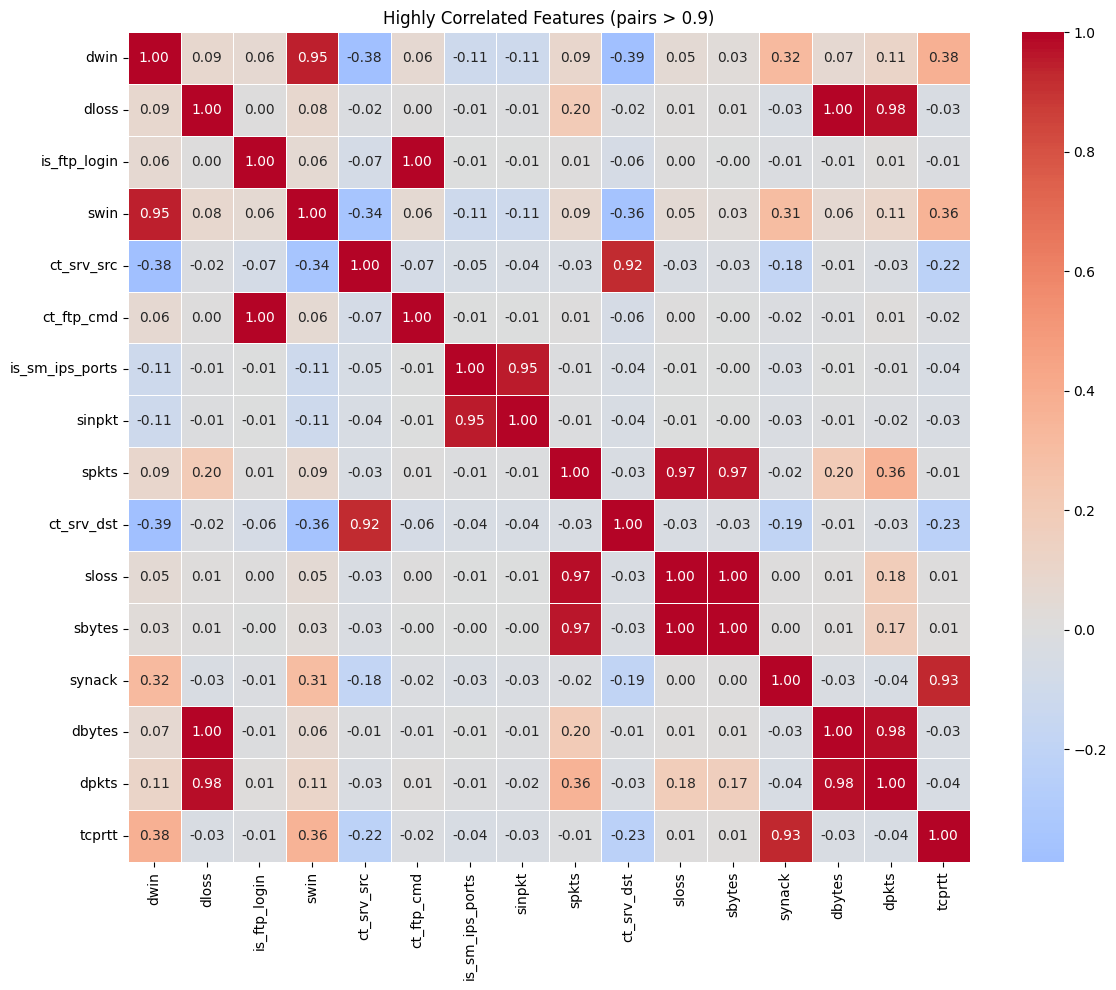

In [63]:
if high_corr:
    corr_features = list(set([f for a, b, _ in high_corr for f in (a, b)]))
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(df[corr_features].corr(), annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=ax, linewidths=0.5)
    ax.set_title('Highly Correlated Features (pairs > 0.9)')
    plt.tight_layout()
    plt.show()
else:
    print("No feature pairs with correlation > 0.9")

## Feature Engineering
Let's conduct an EDA on our features to determine any pre-processing that needs to be done within our dataset, as well as if there are any features to exclude or modify to train our models.

First, drop the irrelevant columns being 'id' and 'attack_cat' as we do not need the id nor are we classifying the attack type (a different problem). Additionally, drop the columns 'stcpb' and 'dtcpb' as they are random TCP sequence numbers and will not contribute to the predictions.

In [64]:
df.drop(['id', 'attack_cat', 'stcpb', 'dtcpb'],axis=1,inplace=True)

Now get categorical vs numerical features

In [65]:
cat_cols = df.select_dtypes(include=['str']).columns.tolist()
num_cols = df.select_dtypes(include='number').columns.difference(['label']).tolist()

print(f"Categorical features ({len(cat_cols)}): {cat_cols}")
print(f"Numerical features  ({len(num_cols)}): {num_cols}")

Categorical features (3): ['proto', 'service', 'state']
Numerical features  (37): ['ackdat', 'ct_dst_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_flw_http_mthd', 'ct_ftp_cmd', 'ct_src_dport_ltm', 'ct_src_ltm', 'ct_srv_dst', 'ct_srv_src', 'ct_state_ttl', 'dbytes', 'dinpkt', 'djit', 'dload', 'dloss', 'dmean', 'dpkts', 'dttl', 'dur', 'dwin', 'is_ftp_login', 'is_sm_ips_ports', 'rate', 'response_body_len', 'sbytes', 'sinpkt', 'sjit', 'sload', 'sloss', 'smean', 'spkts', 'sttl', 'swin', 'synack', 'tcprtt', 'trans_depth']


### Categorical Features — Unique counts & distributions

In [66]:
for col in cat_cols:
    vc = df[col].value_counts()
    print(f"\n{col}  ({vc.shape[0]} unique values)")
    print(vc.to_string())


proto  (131 unique values)
proto
tcp            40559
udp            12541
unas             885
arp              298
ospf             190
sctp              77
any               30
igmp              26
gre               21
rsvp              20
sun-nd            17
emcon             16
nvp               16
ipv6              16
mobile            15
vmtp              15
swipe             15
sep               15
secure-vmtp       15
pim               15
snp               15
prm               12
xns-idp           12
leaf-1            12
bbn-rcc           12
ggp               11
ip                11
ipnip             11
st2               11
argus             11
chaos             11
egp               11
pup               11
xnet              11
mux               11
dcn               11
hmp               11
trunk-1           11
trunk-2           11
leaf-2            11
irtp              11
rdp               11
netblt            11
cbt               11
igp               11
iso-tp4           11


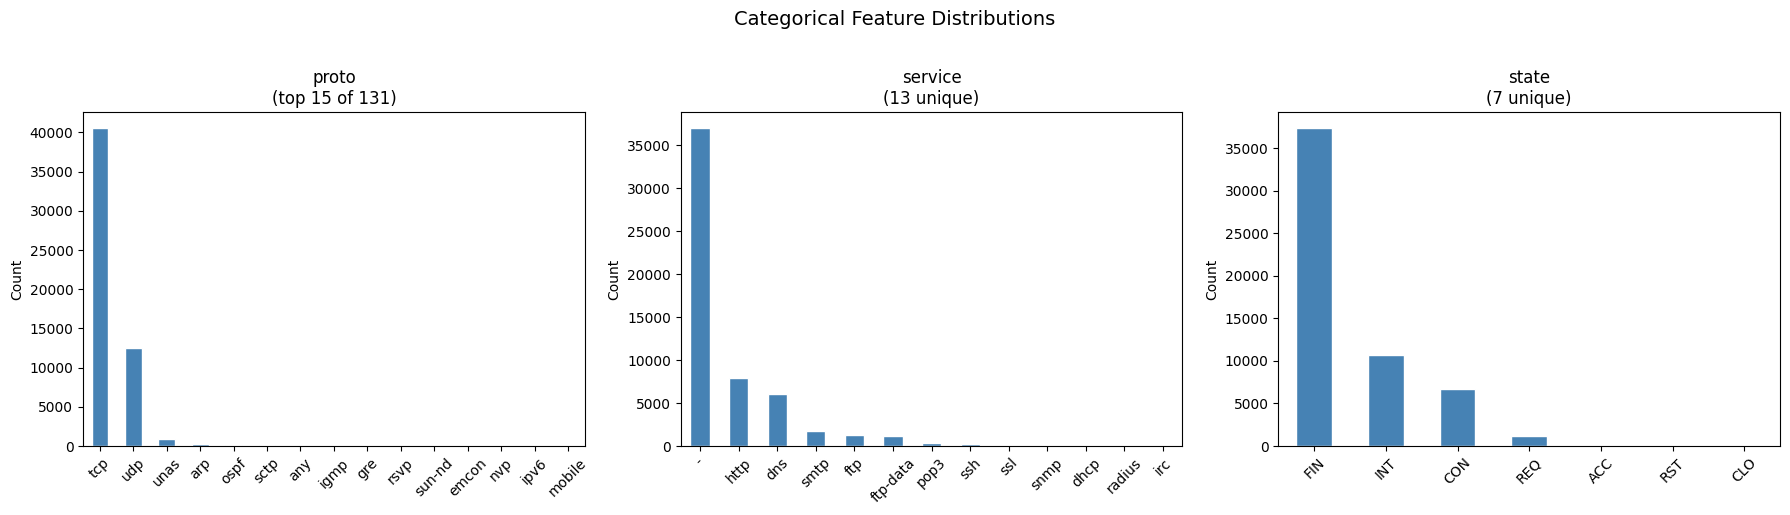

In [67]:
fig, axes = plt.subplots(1, len(cat_cols), figsize=(6 * len(cat_cols), 5))

for ax, col in zip(axes, cat_cols):
    vc = df[col].value_counts()
    # Cap at top 15 as proto has 131 values
    if len(vc) > 15:
        vc = vc.head(15)
        ax.set_title(f'{col}\n(top 15 of {df[col].nunique()})')
    else:
        ax.set_title(f'{col}\n({len(vc)} unique)')
    vc.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Numerical Features

In [68]:
stats = df[num_cols].describe().T[['min', 'max', 'mean', 'std']]
stats['range'] = stats['max'] - stats['min']
stats.sort_values('range', ascending=False).style.format({
    'min':   '{:,.2f}',
    'max':   '{:,.2f}',
    'mean':  '{:,.2f}',
    'std':   '{:,.2f}',
    'range': '{:,.2f}',
})

,min,max,mean,std,range
sload,0.00,"5,268,000,256.00","47,937,489.58","195,319,444.38","5,268,000,256.00"
dload,0.00,"20,821,108.00","924,053.90","2,853,580.82","20,821,108.00"
dbytes,0.00,"14,657,531.00","19,159.21","183,272.14","14,657,531.00"
sbytes,24.00,"14,355,774.00","10,942.35","203,504.65","14,355,750.00"
response_body_len,0.00,"5,242,880.00","2,335.80","46,152.69","5,242,880.00"
sjit,0.00,"1,483,830.92","5,851.75","47,619.86","1,483,830.92"
rate,0.00,"1,000,000.00","41,340.40","117,450.38","1,000,000.00"
djit,0.00,"463,199.24",606.54,"3,834.47","463,199.24"
sinpkt,0.00,"60,009.99",404.68,"4,234.75","60,009.99"
dinpkt,0.00,"57,739.24",111.70,"1,111.66","57,739.24"


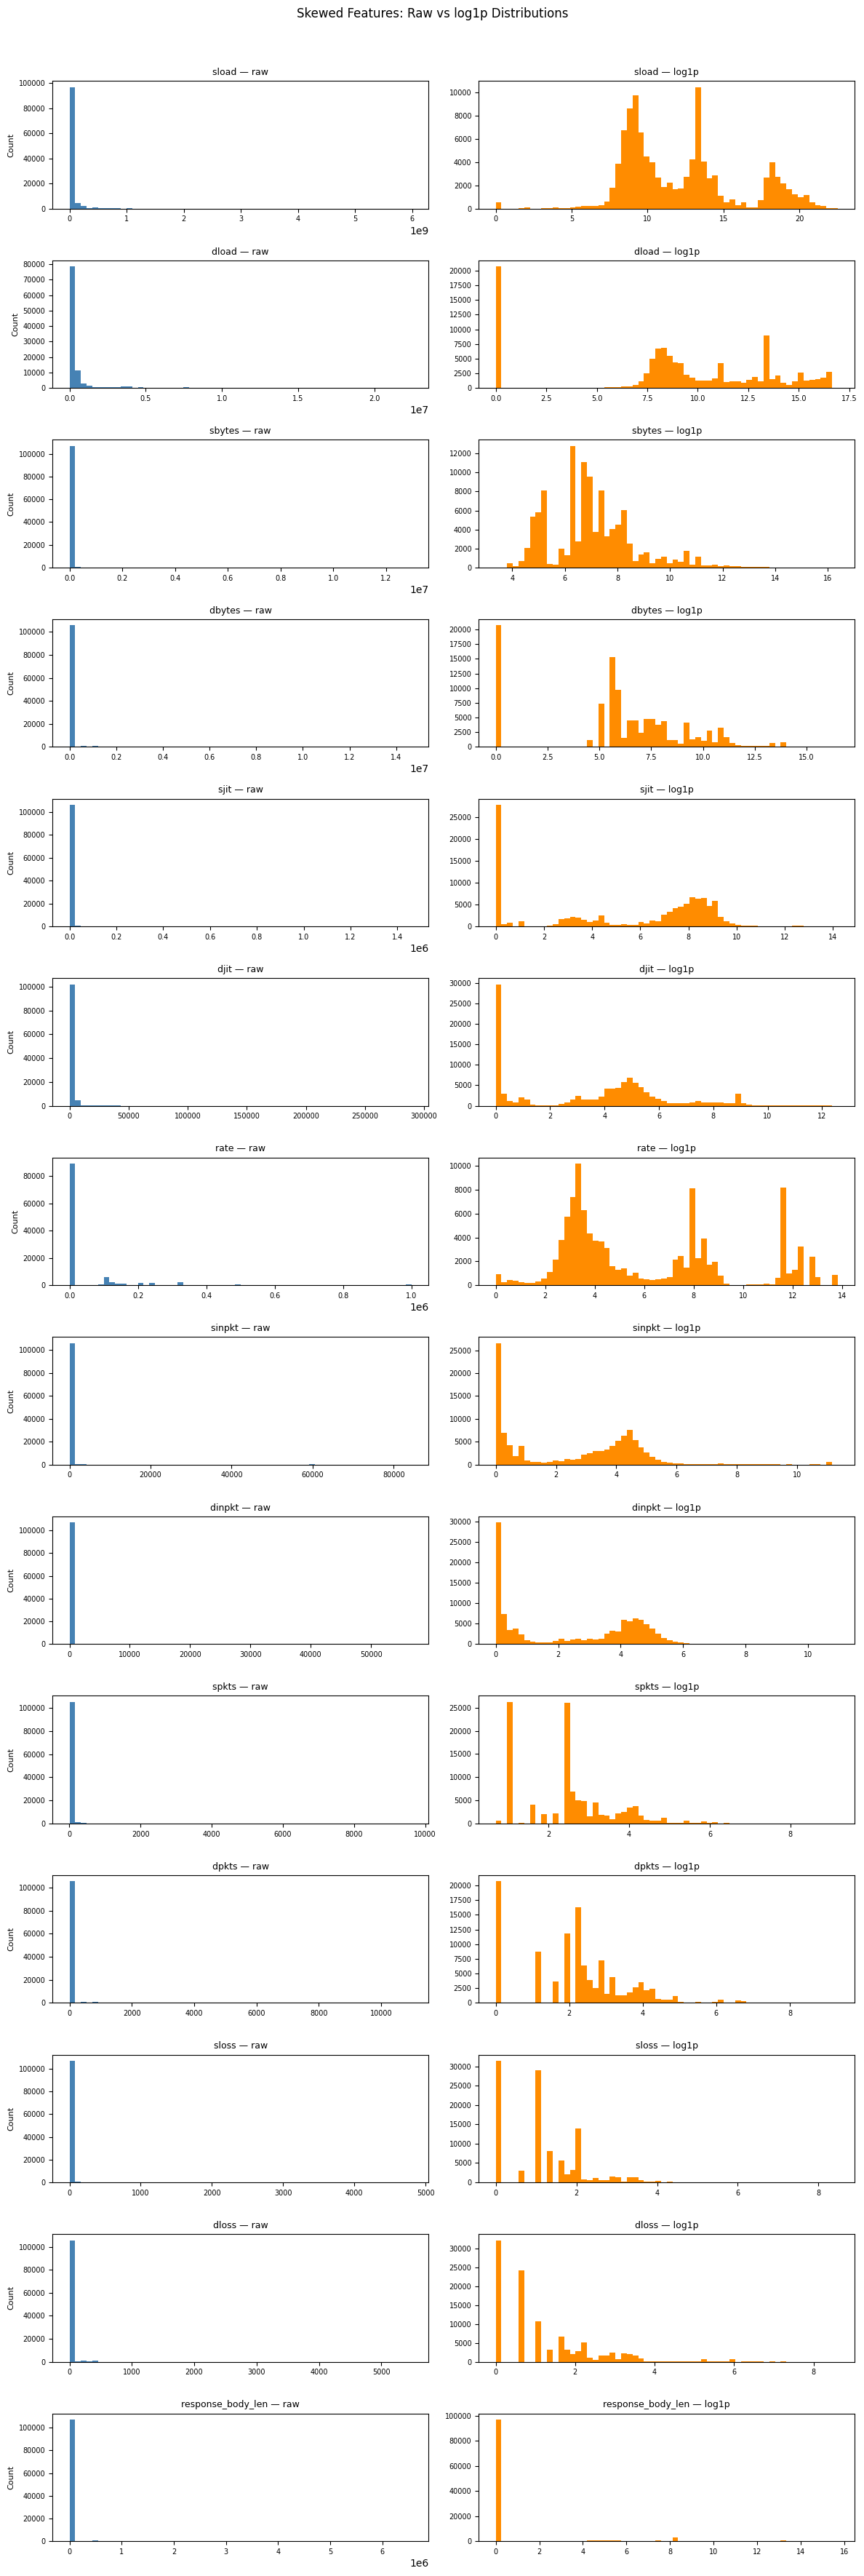

In [53]:
skewed_cols = [
    'sload', 'dload', 'sbytes', 'dbytes', 'sjit', 'djit',
    'rate', 'sinpkt', 'dinpkt', 'spkts', 'dpkts',
    'sloss', 'dloss', 'response_body_len'
]

n = len(skewed_cols)
fig, axes = plt.subplots(n, 2, figsize=(12, n * 2.5))

for i, col in enumerate(skewed_cols):
    raw = df[col].dropna()
    log = np.log1p(raw)

    axes[i, 0].hist(raw, bins=60, color='steelblue', edgecolor='none')
    axes[i, 0].set_title(f'{col} — raw', fontsize=9)
    axes[i, 0].set_ylabel('Count', fontsize=8)
    axes[i, 0].tick_params(labelsize=7)

    axes[i, 1].hist(log, bins=60, color='darkorange', edgecolor='none')
    axes[i, 1].set_title(f'{col} — log1p', fontsize=9)
    axes[i, 1].tick_params(labelsize=7)

plt.suptitle('Skewed Features: Raw vs log1p Distributions', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Preprocessing

### Categorical Variables

We conduct preprocessing based on the results of the EDA above. There are three categorical variables: proto, service, and state. For proto, we can see that only 6 out of its 131 unique categories/values have counts of at least 100 in our dataset of 82 322. To prevent falling under the curse of dimensionality and unnessecary complexity when training our different models, we have made the choice to combine all other categories under one new category named "other", to reduce our unique values from 131 to 7. 

This is the same for the service column, where ...

And for state ..

In [69]:
from sklearn.preprocessing import StandardScaler

proto_filter   = ['tcp', 'udp', 'unas', 'arp', 'ospf', 'sctp']
service_filter = ['-', 'dns', 'http', 'smtp', 'ftp', 'ftp-data', 'ssh', 'pop3']
state_filter  = ['FIN', 'INT', 'CON', 'REQ']

df['proto_filtered']   = df['proto'].where(df['proto'].isin(proto_filter), other='other')
df['service_filtered'] = df['service'].where(df['service'].isin(service_filter), other='other')
df['state_filtered']   = df['state'].where(df['state'].isin(state_filter), other='other')

proto_ohe   = pd.get_dummies(df['proto_filtered'],   prefix='proto')
service_ohe = pd.get_dummies(df['service_filtered'], prefix='service')
state_ohe   = pd.get_dummies(df['state_filtered'],   prefix='state')

ohe_cols = proto_ohe.columns.tolist() + service_ohe.columns.tolist() + state_ohe.columns.tolist()

df = pd.concat([df, proto_ohe, service_ohe, state_ohe], axis=1)

In [70]:
df.columns

Index(['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'dwin', 'tcprtt', 'synack',
       'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len',
       'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm',
       'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd',
       'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports',
       'label', 'proto_filtered', 'service_filtered', 'state_filtered',
       'proto_arp', 'proto_ospf', 'proto_other', 'proto_sctp', 'proto_tcp',
       'proto_udp', 'proto_unas', 'service_-', 'service_dns', 'service_ftp',
       'service_ftp-data', 'service_http', 'service_other', 'service_pop3',
       'service_smtp', 'service_ssh', 'state_CON', 'state_FIN', 'state_INT',
       'state_REQ', 'state_other'],
      dtype='str')

### Numerical Features

Apply StandardScaler to all numerical columns, with scaled columns being added with a _scaled suffix so originals are preserved.

Additionally, there are multiple columns which are right skewed, as shown from the numerical chart and skewed column plots we displayed earlier. We use a log transformation on these columns to handle the skewness so the distribution appears more normal.

In [71]:
skewed_cols = [
    'sload', 'dload', 'sbytes', 'dbytes', 'sjit', 'djit',
    'rate', 'sinpkt', 'dinpkt', 'spkts', 'dpkts',
    'sloss', 'dloss', 'response_body_len'
]
non_skewed_cols = [c for c in num_cols if c not in skewed_cols]

for col in skewed_cols:
    df[f'{col}_log'] = np.log1p(df[col])

log_cols = [f'{col}_log' for col in skewed_cols]

scaler = StandardScaler()
cols_to_scale = log_cols + non_skewed_cols
scaled_values = scaler.fit_transform(df[cols_to_scale])
scaled_cols = [f'{c}_scaled' for c in cols_to_scale]
df = pd.concat([df, pd.DataFrame(scaled_values, columns=scaled_cols, index=df.index)], axis=1)

In [72]:
df

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label,proto_filtered,service_filtered,state_filtered,proto_arp,proto_ospf,proto_other,proto_sctp,proto_tcp,proto_udp,proto_unas,service_-,service_dns,service_ftp,service_ftp-data,service_http,service_other,service_pop3,service_smtp,service_ssh,state_CON,state_FIN,state_INT,state_REQ,state_other,sload_log,dload_log,sbytes_log,dbytes_log,sjit_log,djit_log,rate_log,sinpkt_log,dinpkt_log,spkts_log,dpkts_log,sloss_log,dloss_log,response_body_len_log,sload_log_scaled,dload_log_scaled,sbytes_log_scaled,dbytes_log_scaled,sjit_log_scaled,djit_log_scaled,rate_log_scaled,sinpkt_log_scaled,dinpkt_log_scaled,spkts_log_scaled,dpkts_log_scaled,sloss_log_scaled,dloss_log_scaled,response_body_len_log_scaled,ackdat_scaled,ct_dst_ltm_scaled,ct_dst_sport_ltm_scaled,ct_dst_src_ltm_scaled,ct_flw_http_mthd_scaled,ct_ftp_cmd_scaled,ct_src_dport_ltm_scaled,ct_src_ltm_scaled,ct_srv_dst_scaled,ct_srv_src_scaled,ct_state_ttl_scaled,dmean_scaled,dttl_scaled,dur_scaled,dwin_scaled,is_ftp_login_scaled,is_sm_ips_ports_scaled,smean_scaled,sttl_scaled,swin_scaled,synack_scaled,tcprtt_scaled,trans_depth_scaled
0,0.000011,udp,-,INT,2,0,496,0,90909.090200,254,0,1.803636e+08,0.000000,0,0,0.011000,0.000000,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,248,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,0,udp,-,INT,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,19.010486,0.000000,6.208590,0.000000,0.000000,0.000000,11.417626,0.010940,0.000000,1.098612,0.000000,0.000000,0.000000,0.0,1.761786,-1.649765,-0.419856,-1.650266,-1.405884,-1.200567,1.516892,-1.185791,-1.103353,-1.217874,-1.440439,-1.199338,-0.956103,-0.307674,-0.590835,-0.503144,-0.217036,-0.285107,-0.280678,-0.097247,-0.311272,-0.588983,-0.516027,-0.574568,0.857978,-0.591384,-1.116899,-0.252515,-1.542394,-0.097331,-0.069379,0.340845,0.933831,-1.623348,-0.496312,-0.588361,-0.203984
1,0.000008,udp,-,INT,2,0,1762,0,125000.000300,254,0,8.810000e+08,0.000000,0,0,0.008000,0.000000,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,881,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,0,udp,-,INT,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,20.596568,0.000000,7.474772,0.000000,0.000000,0.000000,11.736077,0.007968,0.000000,1.098612,0.000000,0.000000,0.000000,0.0,2.168308,-1.649765,0.387922,-1.650266,-1.405884,-1.200567,1.606793,-1.187154,-1.103353,-1.217874,-1.440439,-1.199338,-0.956103,-0.307674,-0.590835,-0.503144,-0.217036,-0.285107,-0.280678,-0.097247,-0.311272,-0.588983,-0.516027,-0.574568,0.857978,-0.591384,-1.116899,-0.252515,-1.542394,-0.097331,-0.069379,2.986899,0.933831,-1.623348,-0.496312,-0.588361,-0.203984
2,0.000005,udp,-,INT,2,0,1068,0,200000.005100,254,0,8.544000e+08,0.000000,0,0,0.005000,0.000000,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,534,0,0,0,3,2,1,1,1,3,0,0,0,1,3,0,0,udp,-,INT,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,20.565910,0.000000,6.974479,0.000000,0.000000,0.000000,12.206078,0.004988,0.000000,1.098612,0.000000,0.000000,0.000000,0.0,2.160450,-1.649765,0.068753,-1.650266,-1.405884,-1.200567,1.739477,-1.188520,-1.103353,-1.217874,-1.440439,-1.199338,-0.956103,-0.307674,-0.590835,-0.503144,-0.217036,-0.135725,-0.280678,-0.097247,-0.311272,-0.588983,-0.372357,-0.433238,0.857978,-0.591384,-1.116899,-0.252516,-1.542394,-0.097331,-0.069379,1.536376,0.933831,-1.623348,-0.496312,-0.588361,-0.203984
3,0.000006,udp,-,INT,2,0,900,0,166666.660800,254,0,6.000000e+08,0.000000,0,0,0.006000,0.000000,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,450,0,0,0,3

df_full: every column: originals, log-transformed, OHE, scaled, and label  
df_model: for LR & MLP: OHE + log-then-scaled (skewed) + scaled (non-skewed) + label  
df_model_tree: for RF & XGBoost: OHE + raw numerical columns + label (no scaling needed)

In [73]:
df_full = df.copy()
df_model = df[ohe_cols + scaled_cols + ['label']].copy()
df_model_tree = df[ohe_cols + num_cols + ['label']].copy()

print(f"df_full: {df_full.shape}")
print(f"df_model: {df_model.shape}")
print(f"df_model_tree: {df_model_tree.shape}")

df_full: (55945, 116)
df_model: (55945, 59)
df_model_tree: (55945, 59)


In [74]:
df_full

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label,proto_filtered,service_filtered,state_filtered,proto_arp,proto_ospf,proto_other,proto_sctp,proto_tcp,proto_udp,proto_unas,service_-,service_dns,service_ftp,service_ftp-data,service_http,service_other,service_pop3,service_smtp,service_ssh,state_CON,state_FIN,state_INT,state_REQ,state_other,sload_log,dload_log,sbytes_log,dbytes_log,sjit_log,djit_log,rate_log,sinpkt_log,dinpkt_log,spkts_log,dpkts_log,sloss_log,dloss_log,response_body_len_log,sload_log_scaled,dload_log_scaled,sbytes_log_scaled,dbytes_log_scaled,sjit_log_scaled,djit_log_scaled,rate_log_scaled,sinpkt_log_scaled,dinpkt_log_scaled,spkts_log_scaled,dpkts_log_scaled,sloss_log_scaled,dloss_log_scaled,response_body_len_log_scaled,ackdat_scaled,ct_dst_ltm_scaled,ct_dst_sport_ltm_scaled,ct_dst_src_ltm_scaled,ct_flw_http_mthd_scaled,ct_ftp_cmd_scaled,ct_src_dport_ltm_scaled,ct_src_ltm_scaled,ct_srv_dst_scaled,ct_srv_src_scaled,ct_state_ttl_scaled,dmean_scaled,dttl_scaled,dur_scaled,dwin_scaled,is_ftp_login_scaled,is_sm_ips_ports_scaled,smean_scaled,sttl_scaled,swin_scaled,synack_scaled,tcprtt_scaled,trans_depth_scaled
0,0.000011,udp,-,INT,2,0,496,0,90909.090200,254,0,1.803636e+08,0.000000,0,0,0.011000,0.000000,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,248,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,0,udp,-,INT,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,19.010486,0.000000,6.208590,0.000000,0.000000,0.000000,11.417626,0.010940,0.000000,1.098612,0.000000,0.000000,0.000000,0.0,1.761786,-1.649765,-0.419856,-1.650266,-1.405884,-1.200567,1.516892,-1.185791,-1.103353,-1.217874,-1.440439,-1.199338,-0.956103,-0.307674,-0.590835,-0.503144,-0.217036,-0.285107,-0.280678,-0.097247,-0.311272,-0.588983,-0.516027,-0.574568,0.857978,-0.591384,-1.116899,-0.252515,-1.542394,-0.097331,-0.069379,0.340845,0.933831,-1.623348,-0.496312,-0.588361,-0.203984
1,0.000008,udp,-,INT,2,0,1762,0,125000.000300,254,0,8.810000e+08,0.000000,0,0,0.008000,0.000000,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,881,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,0,udp,-,INT,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,20.596568,0.000000,7.474772,0.000000,0.000000,0.000000,11.736077,0.007968,0.000000,1.098612,0.000000,0.000000,0.000000,0.0,2.168308,-1.649765,0.387922,-1.650266,-1.405884,-1.200567,1.606793,-1.187154,-1.103353,-1.217874,-1.440439,-1.199338,-0.956103,-0.307674,-0.590835,-0.503144,-0.217036,-0.285107,-0.280678,-0.097247,-0.311272,-0.588983,-0.516027,-0.574568,0.857978,-0.591384,-1.116899,-0.252515,-1.542394,-0.097331,-0.069379,2.986899,0.933831,-1.623348,-0.496312,-0.588361,-0.203984
2,0.000005,udp,-,INT,2,0,1068,0,200000.005100,254,0,8.544000e+08,0.000000,0,0,0.005000,0.000000,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,534,0,0,0,3,2,1,1,1,3,0,0,0,1,3,0,0,udp,-,INT,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,20.565910,0.000000,6.974479,0.000000,0.000000,0.000000,12.206078,0.004988,0.000000,1.098612,0.000000,0.000000,0.000000,0.0,2.160450,-1.649765,0.068753,-1.650266,-1.405884,-1.200567,1.739477,-1.188520,-1.103353,-1.217874,-1.440439,-1.199338,-0.956103,-0.307674,-0.590835,-0.503144,-0.217036,-0.135725,-0.280678,-0.097247,-0.311272,-0.588983,-0.372357,-0.433238,0.857978,-0.591384,-1.116899,-0.252516,-1.542394,-0.097331,-0.069379,1.536376,0.933831,-1.623348,-0.496312,-0.588361,-0.203984
3,0.000006,udp,-,INT,2,0,900,0,166666.660800,254,0,6.000000e+08,0.000000,0,0,0.006000,0.000000,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,450,0,0,0,3

In [75]:
df_model

,proto_arp,proto_ospf,proto_other,proto_sctp,proto_tcp,proto_udp,proto_unas,service_-,service_dns,service_ftp,service_ftp-data,service_http,service_other,service_pop3,service_smtp,service_ssh,state_CON,state_FIN,state_INT,state_REQ,state_other,sload_log_scaled,dload_log_scaled,sbytes_log_scaled,dbytes_log_scaled,sjit_log_scaled,djit_log_scaled,rate_log_scaled,sinpkt_log_scaled,dinpkt_log_scaled,spkts_log_scaled,dpkts_log_scaled,sloss_log_scaled,dloss_log_scaled,response_body_len_log_scaled,ackdat_scaled,ct_dst_ltm_scaled,ct_dst_sport_ltm_scaled,ct_dst_src_ltm_scaled,ct_flw_http_mthd_scaled,ct_ftp_cmd_scaled,ct_src_dport_ltm_scaled,ct_src_ltm_scaled,ct_srv_dst_scaled,ct_srv_src_scaled,ct_state_ttl_scaled,dmean_scaled,dttl_scaled,dur_scaled,dwin_scaled,is_ftp_login_scaled,is_sm_ips_ports_scaled,smean_scaled,sttl_scaled,swin_scaled,synack_scaled,tcprtt_scaled,trans_depth_scaled,label
0,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,1.761786,-1.649765,-0.419856,-1.650266,-1.405884,-1.200567,1.516892,-1.185791,-1.103353,-1.217874,-1.440439,-1.199338,-0.956103,-0.307674,-0.590835,-0.503144,-0.217036,-0.285107,-0.280678,-0.097247,-0.311272,-0.588983,-0.516027,-0.574568,0.857978,-0.591384,-1.116899,-0.252515,-1.542394,-0.097331,-0.069379,0.340845,0.933831,-1.623348,-0.496312,-0.588361,-0.203984,0
1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,2.168308,-1.649765,0.387922,-1.650266,-1.405884,-1.200567,1.606793,-1.187154,-1.103353,-1.217874,-1.440439,-1.199338,-0.956103,-0.307674,-0.590835,-0.503144,-0.217036,-0.285107,-0.280678,-0.097247,-0.311272,-0.588983,-0.516027,-0.574568,0.857978,-0.591384,-1.116899,-0.252515,-1.542394,-0.097331,-0.069379,2.986899,0.933831,-1.623348,-0.496312,-0.588361,-0.203984,0
2,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,2.160450,-1.649765,0.068753,-1.650266,-1.405884,-1.200567,1.739477,-1.188520,-1.103353,-1.217874,-1.440439,-1.199338,-0.956103,-0.307674,-0.590835,-0.503144,-0.217036,-0.135725,-0.280678,-0.097247,-0.311272,-0.588983,-0.372357,-0.433238,0.857978,-0.591384,-1.116899,-0.252516,-1.542394,-0.097331,-0.069379,1.536376,0.933831,-1.623348,-0.496312,-0.588361,-0.203984,0
3,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,2.069854,-1.649765,-0.040322,-1.650266,-1.405884,-1.200567,1.688007,-1.188064,-1.103353,-1.217874,-1.440439,-1.199338,-0.956103,-0.307674,-0.590835,-0.282654,-0.217036,-0.135725,-0.280678,-0.097247,-0.058123,-0.385295,-0.372357,-0.433238,0.857978,-0.591384,-1.116899,-0.252516,-1.542394,-0.097331,-0.069379,1.185241,0.933831,-1.623348,-0.496312,-0.588361,-0.203984,0
4,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,2.159247,-1.649765,0.507665,-1.650266,-1.405884,-1.200567,1.543799,-1.186245,-1.103353,-1.217874,-1.440439,-1.199338,-0.956103,-0.307674,-0.590835,-0.282654,-0.217036,-0.135725,-0.280678,-0.097247,-0.058123,-0.385295,-0.372357,-0.433238,0.857978,-0.591384,-1.116899,-0.252515,-1.542394,-0.097331,-0.069379,3.747693,0.933831,-1.623348,-0.496312,-0.588361,-0.203984,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55940,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,-0.916508,-0.109794,-0.311507,-0.002247,0.836227,0.727900,-0.868175,0.841489,1.161766,-0.003422,-0.052435,-0.049192,-0.345548,-0.307674,1.329251,-0.503144,-0.217036,0.013658,-0.280678,-0.097247,-0.311272,-0.588983,-0.228687,-0.291907,-0.065322,-0.429739,1.020781,-0.054004,0.64846

In [76]:
df_model.columns

Index(['proto_arp', 'proto_ospf', 'proto_other', 'proto_sctp', 'proto_tcp',
       'proto_udp', 'proto_unas', 'service_-', 'service_dns', 'service_ftp',
       'service_ftp-data', 'service_http', 'service_other', 'service_pop3',
       'service_smtp', 'service_ssh', 'state_CON', 'state_FIN', 'state_INT',
       'state_REQ', 'state_other', 'sload_log_scaled', 'dload_log_scaled',
       'sbytes_log_scaled', 'dbytes_log_scaled', 'sjit_log_scaled',
       'djit_log_scaled', 'rate_log_scaled', 'sinpkt_log_scaled',
       'dinpkt_log_scaled', 'spkts_log_scaled', 'dpkts_log_scaled',
       'sloss_log_scaled', 'dloss_log_scaled', 'response_body_len_log_scaled',
       'ackdat_scaled', 'ct_dst_ltm_scaled', 'ct_dst_sport_ltm_scaled',
       'ct_dst_src_ltm_scaled', 'ct_flw_http_mthd_scaled', 'ct_ftp_cmd_scaled',
       'ct_src_dport_ltm_scaled', 'ct_src_ltm_scaled', 'ct_srv_dst_scaled',
       'ct_srv_src_scaled', 'ct_state_ttl_scaled', 'dmean_scaled',
       'dttl_scaled', 'dur_scaled', 'dwin_s

In [77]:
df_model_tree

,proto_arp,proto_ospf,proto_other,proto_sctp,proto_tcp,proto_udp,proto_unas,service_-,service_dns,service_ftp,service_ftp-data,service_http,service_other,service_pop3,service_smtp,service_ssh,state_CON,state_FIN,state_INT,state_REQ,state_other,ackdat,ct_dst_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,ct_flw_http_mthd,ct_ftp_cmd,ct_src_dport_ltm,ct_src_ltm,ct_srv_dst,ct_srv_src,ct_state_ttl,dbytes,dinpkt,djit,dload,dloss,dmean,dpkts,dttl,dur,dwin,is_ftp_login,is_sm_ips_ports,rate,response_body_len,sbytes,sinpkt,sjit,sload,sloss,smean,spkts,sttl,swin,synack,tcprtt,trans_depth,label
0,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,0.000000,1,1,2,0,0,1,1,2,2,2,0,0.000000,0.000000,0.000000,0,0,0,0,0.000011,0,0,0,90909.090200,0,496,0.011000,0.000000,1.803636e+08,0,248,2,254,0,0.000000,0.000000,0,0
1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,0.000000,1,1,2,0,0,1,1,2,2,2,0,0.000000,0.000000,0.000000,0,0,0,0,0.000008,0,0,0,125000.000300,0,1762,0.008000,0.000000,8.810000e+08,0,881,2,254,0,0.000000,0.000000,0,0
2,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,0.000000,1,1,3,0,0,1,1,3,3,2,0,0.000000,0.000000,0.000000,0,0,0,0,0.000005,0,0,0,200000.005100,0,1068,0.005000,0.000000,8.544000e+08,0,534,2,254,0,0.000000,0.000000,0,0
3,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,0.000000,2,1,3,0,0,2,2,3,3,2,0,0.000000,0.000000,0.000000,0,0,0,0,0.000006,0,0,0,166666.660800,0,900,0.006000,0.000000,6.000000e+08,0,450,2,254,0,0.000000,0.000000,0,0
4,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,0.000000,2,1,3,0,0,2,2,3,3,2,0,0.000000,0.000000,0.000000,0,0,0,0,0.000010,0,0,0,100000.002500,0,2126,0.010000,0.000000,8.504000e+08,0,1063,2,254,0,0.000000,0.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55940,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,0.119658,1,1,4,0,0,1,1,4,4,1,268,138.888594,195.623781,2207.130127,1,45,6,252,0.811914,255,0,0,18.474862,0,588,83.216333,4368.102356,5.222228e+03,2,59,10,254,255,0.117467,0.237125,0,0
55941,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,0.000000,1,1,1,0,0,1,1,1,1,2,0,0.000000,0.000000,0.000000,0,0,0,0,0.000004,0,0,0,250000.000600,0,104,0.004000,0.000000,1.040000e+08,0,52,2,254,0,0.000000,0.000000,0,0
55942,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,0.059860,1,1,1,0,0,1,1,3,1,1,1042,221.155219,559.560500,1546.616211,1,43,24,252,5.167410,255,0,0,25.351192,0,138067,48.287767,9709.118613,2.117719e+05,51,1278,108,254,255,0.080831,0.140691,0,0
55943,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,0.000000,2,1,2,0,0,1,2,1,1,2,0,0.000000,0.000000,0.000000,0,0,0,0,0.000005,0,0,0,200000.005100,0,104,0.005000,0.000000,8.320000e+07,0,52,2,254,0,0.000000,0.000000,0,0


In [78]:
df_model_tree.columns

Index(['proto_arp', 'proto_ospf', 'proto_other', 'proto_sctp', 'proto_tcp',
       'proto_udp', 'proto_unas', 'service_-', 'service_dns', 'service_ftp',
       'service_ftp-data', 'service_http', 'service_other', 'service_pop3',
       'service_smtp', 'service_ssh', 'state_CON', 'state_FIN', 'state_INT',
       'state_REQ', 'state_other', 'ackdat', 'ct_dst_ltm', 'ct_dst_sport_ltm',
       'ct_dst_src_ltm', 'ct_flw_http_mthd', 'ct_ftp_cmd', 'ct_src_dport_ltm',
       'ct_src_ltm', 'ct_srv_dst', 'ct_srv_src', 'ct_state_ttl', 'dbytes',
       'dinpkt', 'djit', 'dload', 'dloss', 'dmean', 'dpkts', 'dttl', 'dur',
       'dwin', 'is_ftp_login', 'is_sm_ips_ports', 'rate', 'response_body_len',
       'sbytes', 'sinpkt', 'sjit', 'sload', 'sloss', 'smean', 'spkts', 'sttl',
       'swin', 'synack', 'tcprtt', 'trans_depth', 'label'],
      dtype='str')

In [79]:
df_full.to_csv("../data/processed/training_full.csv", index=False)
df_model.to_csv("../data/processed/training_lr_mlp.csv", index=False)
df_model_tree.to_csv("../data/processed/training_xgb_rf.csv", index=False)

## Preprocessing Pipeline 

Using preprocessing.py

In [80]:
df_full = pd.read_csv("../data/processed/training_full.csv")
df_model = pd.read_csv("../data/processed/training_lr_mlp.csv")
df_model_tree = pd.read_csv("../data/processed/training_xgb_rf.csv")

In [81]:
import sys
sys.path.append('../src')

from preprocessing.preprocessing import preprocess_train, preprocess_test, save_artifacts

raw_train = pd.read_csv('../data/raw/UNSW_NB15_training-set.csv')
raw_test  = pd.read_csv('../data/raw/UNSW_NB15_testing-set.csv')

fn_full, fn_model, fn_model_tree, artifacts = preprocess_train(raw_train)

print(f"fn_full       shape: {fn_full.shape}")
print(f"fn_model      shape: {fn_model.shape}")
print(f"fn_model_tree shape: {fn_model_tree.shape}")

fn_full       shape: (55945, 116)
fn_model      shape: (55945, 59)
fn_model_tree shape: (55945, 59)


In [82]:
save_artifacts(artifacts, '../data/processed/artifacts.pkl')

test_full, test_model, test_model_tree = preprocess_test(raw_test, artifacts)

test_full.to_csv('../data/processed/test_full.csv', index=False)
test_model.to_csv('../data/processed/test_lr_mlp.csv', index=False)
test_model_tree.to_csv('../data/processed/test_xgb_rf.csv', index=False)

print(f"test_full       shape: {test_full.shape}")
print(f"test_model      shape: {test_model.shape}")
print(f"test_model_tree shape: {test_model_tree.shape}")

Artifacts saved to ../data/processed/artifacts.pkl
test_full       shape: (107740, 116)
test_model      shape: (107740, 59)
test_model_tree shape: (107740, 59)
